In [6]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mlg-ulb/creditcardfraud/creditcard.csv


In [7]:
# Install and imports

!pip install imbalanced-learn shap -q

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             classification_report, confusion_matrix,
                             roc_curve, precision_recall_curve, f1_score,
                             precision_score, recall_score)

import xgboost as xgb
import lightgbm as lgb
import shap

from imblearn.over_sampling import SMOTE, ADASYN, BorderlineSMOTE

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

os.makedirs('images', exist_ok=True)

Using device: cuda


In [8]:
# Load data

DATA_PATH = '/kaggle/input/datasets/mlg-ulb/creditcardfraud'
df = pd.read_csv(f'{DATA_PATH}/creditcard.csv')

print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nClass distribution:")
print(df['Class'].value_counts())
print(f"\nFraud rate: {df['Class'].mean():.4%}")

Shape: (284807, 31)

Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud rate: 0.1727%


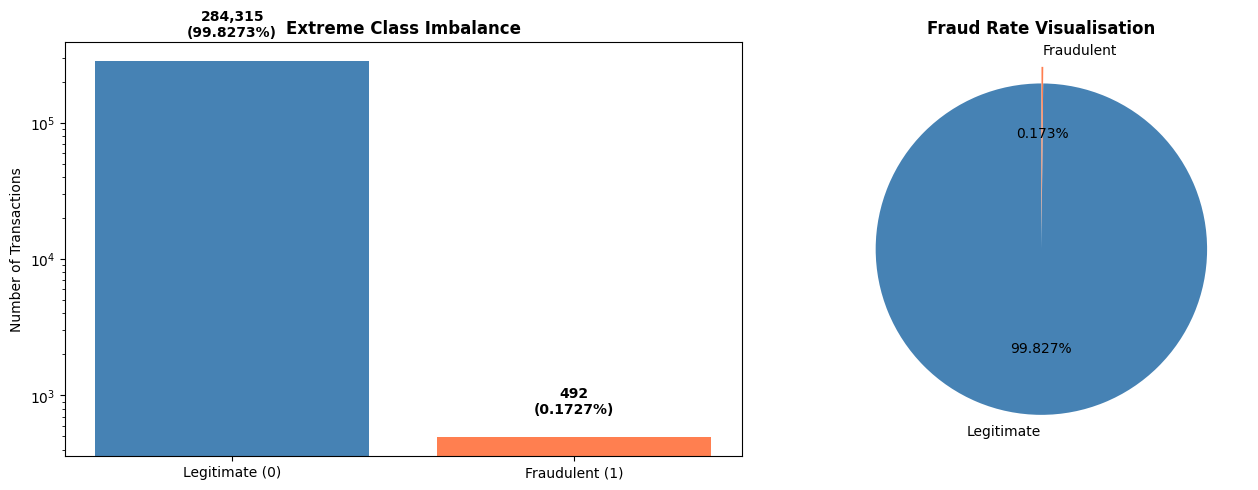

In [9]:
# Class imbalance visualisation

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

class_counts = df['Class'].value_counts()
axes[0].bar(['Legitimate (0)', 'Fraudulent (1)'], class_counts.values,
            color=['steelblue', 'coral'])
axes[0].set_title('Extreme Class Imbalance', fontweight='bold')
axes[0].set_ylabel('Number of Transactions')
axes[0].set_yscale('log')

for i, v in enumerate(class_counts.values):
    pct = v / len(df) * 100
    axes[0].text(i, v * 1.5, f'{v:,}\n({pct:.4f}%)', ha='center', fontweight='bold')

axes[1].pie(class_counts.values, labels=['Legitimate', 'Fraudulent'],
            colors=['steelblue', 'coral'], autopct='%1.3f%%',
            explode=[0, 0.1], startangle=90)
axes[1].set_title('Fraud Rate Visualisation', fontweight='bold')

plt.tight_layout()
plt.savefig('images/class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()

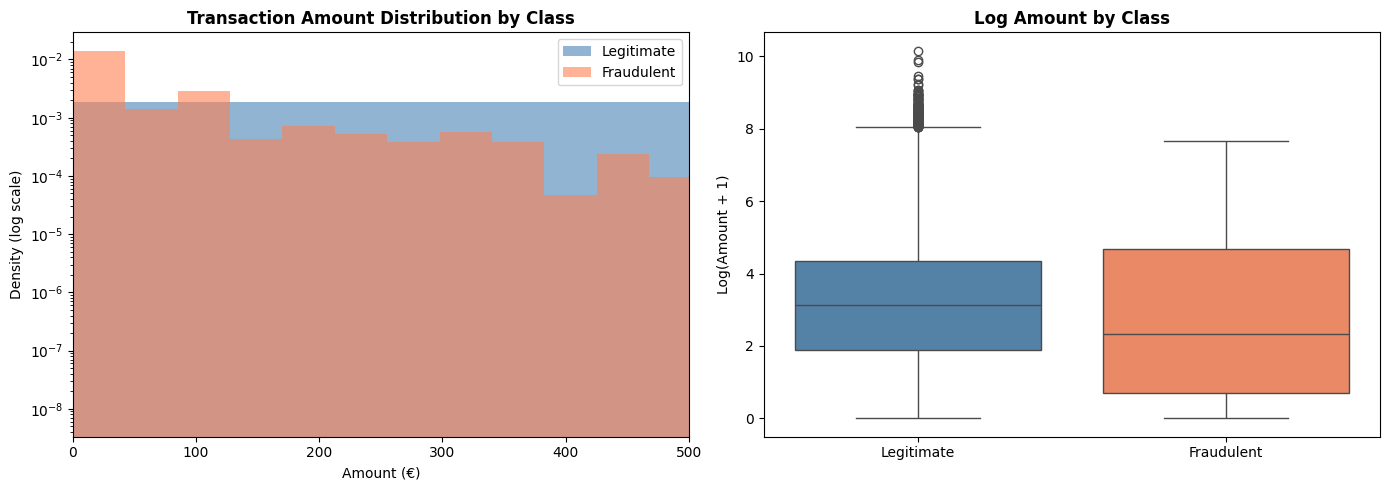


Statistical summary:
          count        mean         std  min   25%    50%     75%       max
Class                                                                      
0      284315.0   88.291022  250.105092  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.211321  256.683288  0.0  1.00   9.25  105.89   2125.87


In [10]:
# Transaction amount distribution by class

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Amount distribution
for label, color in [(0, 'steelblue'), (1, 'coral')]:
    subset = df[df['Class'] == label]
    axes[0].hist(subset['Amount'], bins=50, alpha=0.6, color=color,
                 label='Legitimate' if label == 0 else 'Fraudulent',
                 density=True)

axes[0].set_yscale('log')
axes[0].set_xlim(0, 500)
axes[0].set_title('Transaction Amount Distribution by Class', fontweight='bold')
axes[0].set_xlabel('Amount (€)')
axes[0].set_ylabel('Density (log scale)')
axes[0].legend()

# Log amount box plot
df['LogAmount'] = np.log1p(df['Amount'])
sns.boxplot(data=df, x='Class', y='LogAmount', ax=axes[1],
            palette=['steelblue', 'coral'])
axes[1].set_xticklabels(['Legitimate', 'Fraudulent'])
axes[1].set_title('Log Amount by Class', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Log(Amount + 1)')

plt.tight_layout()
plt.savefig('images/transaction_amount_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nStatistical summary:")
print(df.groupby('Class')['Amount'].describe())

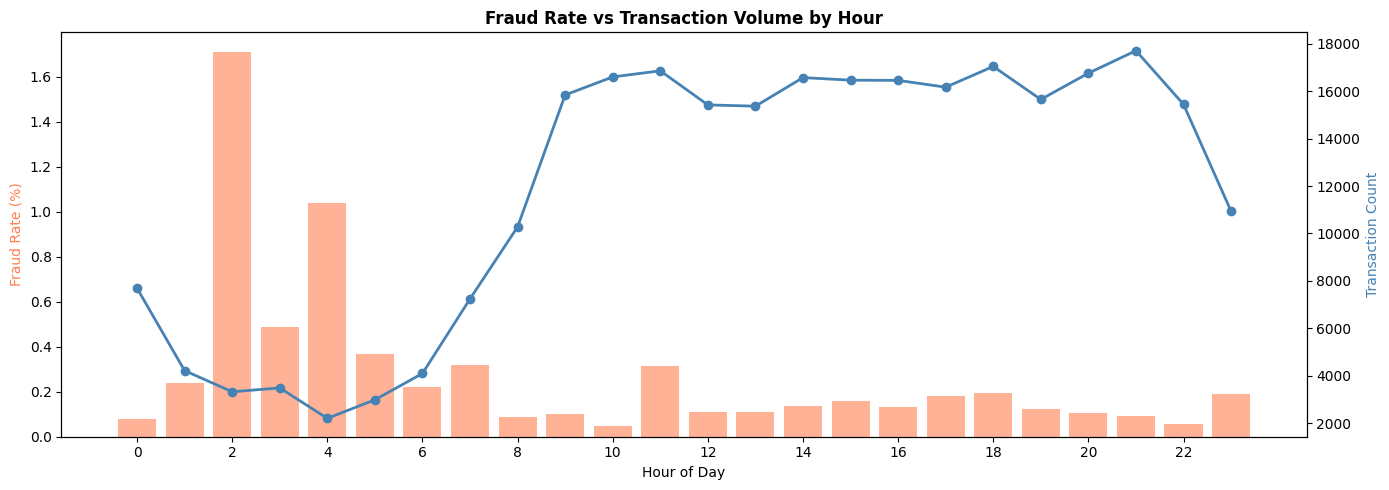

In [11]:
# Time pattern analysis

# Convert Time (seconds) to hours
df['Hour'] = (df['Time'] // 3600) % 24

fig, ax = plt.subplots(figsize=(14, 5))

fraud_rate_by_hour = df.groupby('Hour')['Class'].mean() * 100
transaction_count_by_hour = df.groupby('Hour').size()

ax2 = ax.twinx()

ax.bar(fraud_rate_by_hour.index, fraud_rate_by_hour.values,
       alpha=0.6, color='coral', label='Fraud Rate (%)')
ax2.plot(transaction_count_by_hour.index, transaction_count_by_hour.values,
         color='steelblue', linewidth=2, marker='o', label='Transaction Count')

ax.set_xlabel('Hour of Day')
ax.set_ylabel('Fraud Rate (%)', color='coral')
ax2.set_ylabel('Transaction Count', color='steelblue')
ax.set_title('Fraud Rate vs Transaction Volume by Hour', fontweight='bold')
ax.set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.savefig('images/time_pattern_analysis.png', dpi=150, bbox_inches='tight')
plt.show()



In [12]:
# Preprocessing

# Drop the Hour and LogAmount helper columns
df = df.drop(columns=['Hour', 'LogAmount'], errors='ignore')

X = df.drop(columns=['Class'])
y = df['Class']

# Stratified split preserves the class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Standardise features (important for Logistic Regression, autoencoder)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train fraud rate: {y_train.mean():.4%}")
print(f"Test fraud rate: {y_test.mean():.4%}")

Train: (227845, 30), Test: (56962, 30)
Train fraud rate: 0.1729%
Test fraud rate: 0.1720%


In [13]:
# Baseline: Logistic Regression (no rebalancing)

lr_baseline = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
lr_baseline.fit(X_train_scaled, y_train)
lr_prob = lr_baseline.predict_proba(X_test_scaled)[:, 1]
lr_pred = lr_baseline.predict(X_test_scaled)

lr_auc = roc_auc_score(y_test, lr_prob)
lr_ap = average_precision_score(y_test, lr_prob)
lr_f1 = f1_score(y_test, lr_pred)

print(f"Logistic Regression (baseline)")
print(f"  ROC-AUC: {lr_auc:.4f}")
print(f"  PR-AUC:  {lr_ap:.4f}")
print(f"  F1 (default threshold): {lr_f1:.4f}")
print(f"  Recall (fraud caught): {recall_score(y_test, lr_pred):.4f}")

Logistic Regression (baseline)
  ROC-AUC: 0.9605
  PR-AUC:  0.7414
  F1 (default threshold): 0.7168
  Recall (fraud caught): 0.6327


In [14]:
# Compare SMOTE variants

from imblearn.over_sampling import SMOTE, ADASYN, BorderlineSMOTE

resampling_techniques = {
    'SMOTE': SMOTE(random_state=42),
    'BorderlineSMOTE': BorderlineSMOTE(random_state=42),
    'ADASYN': ADASYN(random_state=42),
}

results = {}
for name, sampler in resampling_techniques.items():
    print(f"Applying {name}...")
    X_res, y_res = sampler.fit_resample(X_train_scaled, y_train)

    model = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
    model.fit(X_res, y_res)
    prob = model.predict_proba(X_test_scaled)[:, 1]

    results[name] = {
        'auc': roc_auc_score(y_test, prob),
        'ap': average_precision_score(y_test, prob),
        'model': model,
        'prob': prob,
    }
    print(f"  ROC-AUC: {results[name]['auc']:.4f}, PR-AUC: {results[name]['ap']:.4f}")

Applying SMOTE...
  ROC-AUC: 0.9708, PR-AUC: 0.7245
Applying BorderlineSMOTE...
  ROC-AUC: 0.9473, PR-AUC: 0.6958
Applying ADASYN...
  ROC-AUC: 0.9734, PR-AUC: 0.7304


In [15]:
# XGBoost and LightGBM with class weighting

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# XGBoost
xgb_model = xgb.XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    scale_pos_weight=scale_pos_weight, random_state=42,
    eval_metric='aucpr', tree_method='hist')
xgb_model.fit(X_train, y_train)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]
xgb_auc = roc_auc_score(y_test, xgb_prob)
xgb_ap = average_precision_score(y_test, xgb_prob)
print(f"XGBoost — ROC-AUC: {xgb_auc:.4f}, PR-AUC: {xgb_ap:.4f}")

# LightGBM
lgb_model = lgb.LGBMClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    class_weight='balanced', random_state=42, verbose=-1)
lgb_model.fit(X_train, y_train)
lgb_prob = lgb_model.predict_proba(X_test)[:, 1]
lgb_auc = roc_auc_score(y_test, lgb_prob)
lgb_ap = average_precision_score(y_test, lgb_prob)
print(f"LightGBM — ROC-AUC: {lgb_auc:.4f}, PR-AUC: {lgb_ap:.4f}")

XGBoost — ROC-AUC: 0.9684, PR-AUC: 0.8787
LightGBM — ROC-AUC: 0.9742, PR-AUC: 0.8648


Isolation Forest — ROC-AUC: 0.9531, PR-AUC: 0.1283


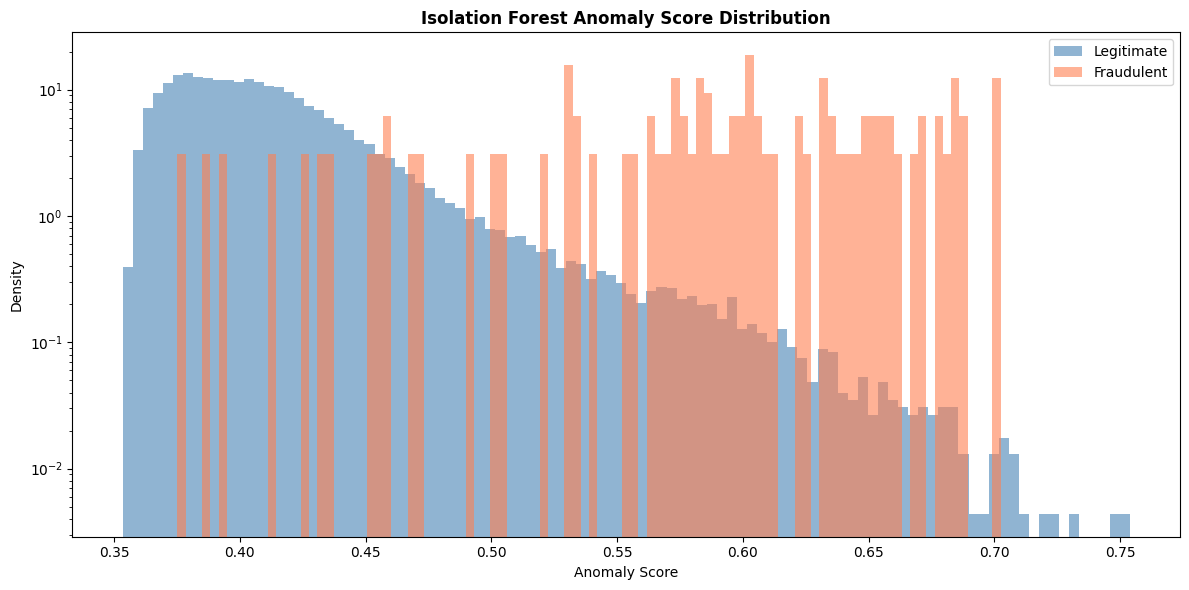

In [16]:
# Unsupervised Anomaly Detection
# Isolation Forest

# Train only on legitimate transactions
legit_train = X_train_scaled[y_train == 0]

iso_forest = IsolationForest(
    n_estimators=200, contamination=0.002,
    random_state=42, n_jobs=-1)
iso_forest.fit(legit_train)

# Higher score = more normal, lower = anomalous
iso_scores = -iso_forest.score_samples(X_test_scaled)
iso_pred = (iso_scores > np.percentile(iso_scores, 99.83)).astype(int)

iso_auc = roc_auc_score(y_test, iso_scores)
iso_ap = average_precision_score(y_test, iso_scores)
print(f"Isolation Forest — ROC-AUC: {iso_auc:.4f}, PR-AUC: {iso_ap:.4f}")

# Visualise
fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(iso_scores[y_test == 0], bins=100, alpha=0.6, color='steelblue', label='Legitimate', density=True)
ax.hist(iso_scores[y_test == 1], bins=100, alpha=0.6, color='coral', label='Fraudulent', density=True)
ax.set_xlabel('Anomaly Score')
ax.set_ylabel('Density')
ax.set_title('Isolation Forest Anomaly Score Distribution', fontweight='bold')
ax.legend()
ax.set_yscale('log')
plt.tight_layout()
plt.savefig('images/isolation_forest_scores.png', dpi=150, bbox_inches='tight')
plt.show()

Training autoencoder on legitimate transactions only...
Epoch 5/20 — Loss: 0.537647
Epoch 10/20 — Loss: 0.501745
Epoch 15/20 — Loss: 0.490390
Epoch 20/20 — Loss: 0.449886

Autoencoder — ROC-AUC: 0.9435, PR-AUC: 0.2975


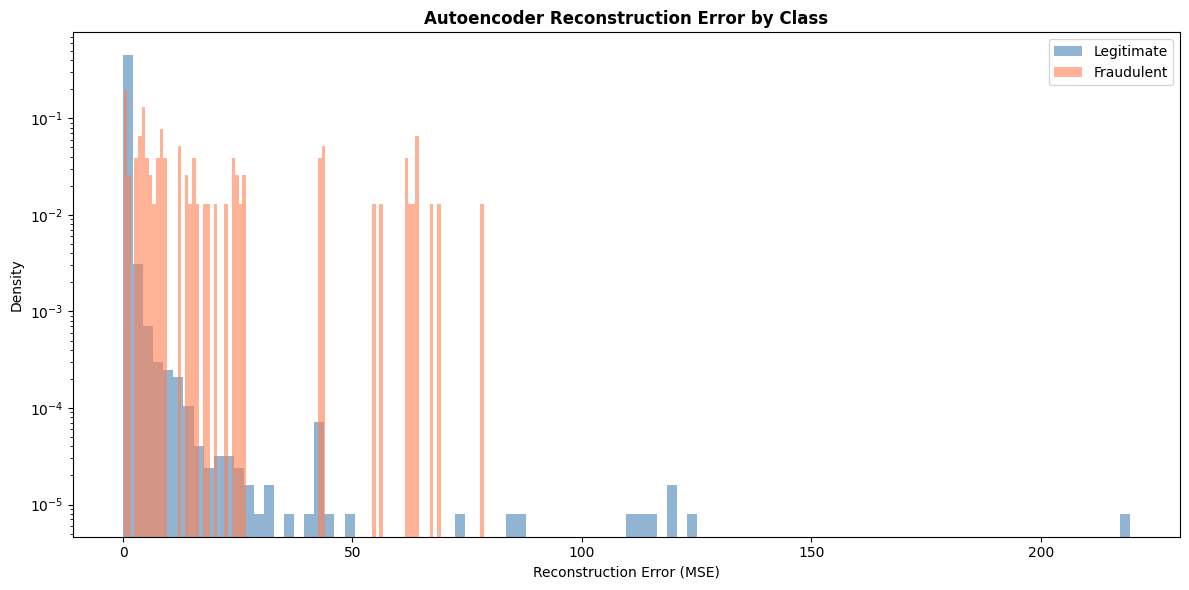

In [17]:
# Autoencoder for anomaly detection

# Train autoencoder ONLY on legitimate transactions
legit_train_tensor = torch.FloatTensor(legit_train).to(device)
train_loader = DataLoader(TensorDataset(legit_train_tensor), batch_size=256, shuffle=True)

class Autoencoder(nn.Module):
    def __init__(self, input_dim=30):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 20), nn.ReLU(),
            nn.Linear(20, 14), nn.ReLU(),
            nn.Linear(14, 8), nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(8, 14), nn.ReLU(),
            nn.Linear(14, 20), nn.ReLU(),
            nn.Linear(20, input_dim),
        )
    def forward(self, x):
        return self.decoder(self.encoder(x))

autoencoder = Autoencoder(input_dim=X_train_scaled.shape[1]).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(autoencoder.parameters(), lr=1e-3)

NUM_EPOCHS = 20
train_losses = []

print("Training autoencoder on legitimate transactions only...")
for epoch in range(NUM_EPOCHS):
    autoencoder.train()
    epoch_loss = 0
    for (batch,) in train_loader:
        optimizer.zero_grad()
        reconstruction = autoencoder(batch)
        loss = criterion(reconstruction, batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    train_losses.append(epoch_loss / len(train_loader))
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{NUM_EPOCHS} — Loss: {train_losses[-1]:.6f}")

# Reconstruction error on test set
autoencoder.eval()
with torch.no_grad():
    X_test_tensor = torch.FloatTensor(X_test_scaled).to(device)
    reconstruction = autoencoder(X_test_tensor).cpu().numpy()

reconstruction_error = np.mean((X_test_scaled - reconstruction) ** 2, axis=1)

ae_auc = roc_auc_score(y_test, reconstruction_error)
ae_ap = average_precision_score(y_test, reconstruction_error)
print(f"\nAutoencoder — ROC-AUC: {ae_auc:.4f}, PR-AUC: {ae_ap:.4f}")

# Visualise reconstruction error distributions
fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(reconstruction_error[y_test == 0], bins=100, alpha=0.6, color='steelblue', label='Legitimate', density=True)
ax.hist(reconstruction_error[y_test == 1], bins=100, alpha=0.6, color='coral', label='Fraudulent', density=True)
ax.set_xlabel('Reconstruction Error (MSE)')
ax.set_ylabel('Density')
ax.set_title('Autoencoder Reconstruction Error by Class', fontweight='bold')
ax.legend()
ax.set_yscale('log')
plt.tight_layout()
plt.savefig('images/autoencoder_reconstruction_error.png', dpi=150, bbox_inches='tight')
plt.show()

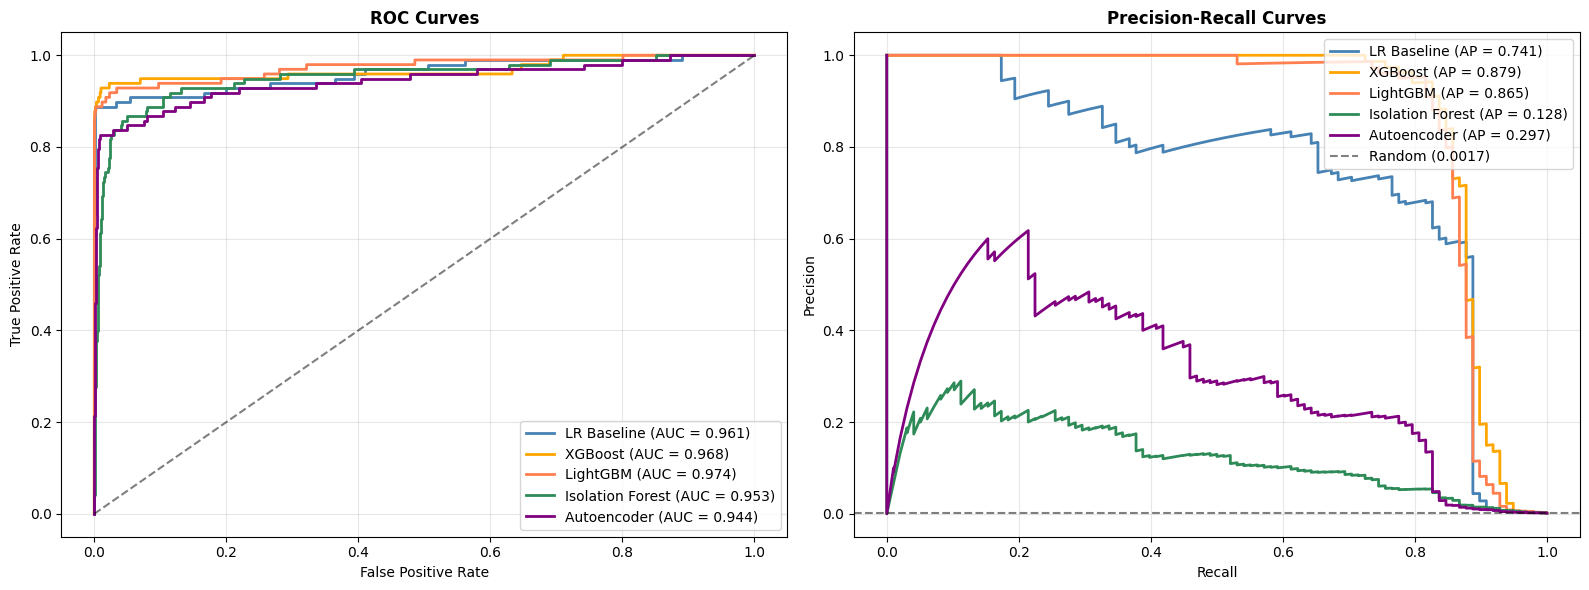


Final comparison table:
Model                   ROC-AUC     PR-AUC
------------------------------------------
LR Baseline              0.9605     0.7414
XGBoost                  0.9684     0.8787
LightGBM                 0.9742     0.8648
Isolation Forest         0.9531     0.1283
Autoencoder              0.9435     0.2975


In [18]:
# Compare all models: ROC and PR curves

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROC curves
models_summary = [
    ('LR Baseline', lr_prob, lr_auc, lr_ap, 'steelblue'),
    ('XGBoost', xgb_prob, xgb_auc, xgb_ap, 'orange'),
    ('LightGBM', lgb_prob, lgb_auc, lgb_ap, 'coral'),
    ('Isolation Forest', iso_scores / iso_scores.max(), iso_auc, iso_ap, 'seagreen'),
    ('Autoencoder', reconstruction_error / reconstruction_error.max(), ae_auc, ae_ap, 'purple'),
]

for name, prob, auc, ap, color in models_summary:
    fpr, tpr, _ = roc_curve(y_test, prob)
    axes[0].plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC = {auc:.3f})')

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves', fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

for name, prob, auc, ap, color in models_summary:
    precision, recall, _ = precision_recall_curve(y_test, prob)
    axes[1].plot(recall, precision, color=color, linewidth=2, label=f'{name} (AP = {ap:.3f})')

axes[1].axhline(y=y_test.mean(), color='k', linestyle='--', alpha=0.5, label=f'Random ({y_test.mean():.4f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves', fontweight='bold')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('images/model_comparison_roc_pr.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFinal comparison table:")
print(f"{'Model':<20} {'ROC-AUC':>10} {'PR-AUC':>10}")
print("-" * 42)
for name, _, auc, ap, _ in models_summary:
    print(f"{name:<20} {auc:>10.4f} {ap:>10.4f}")

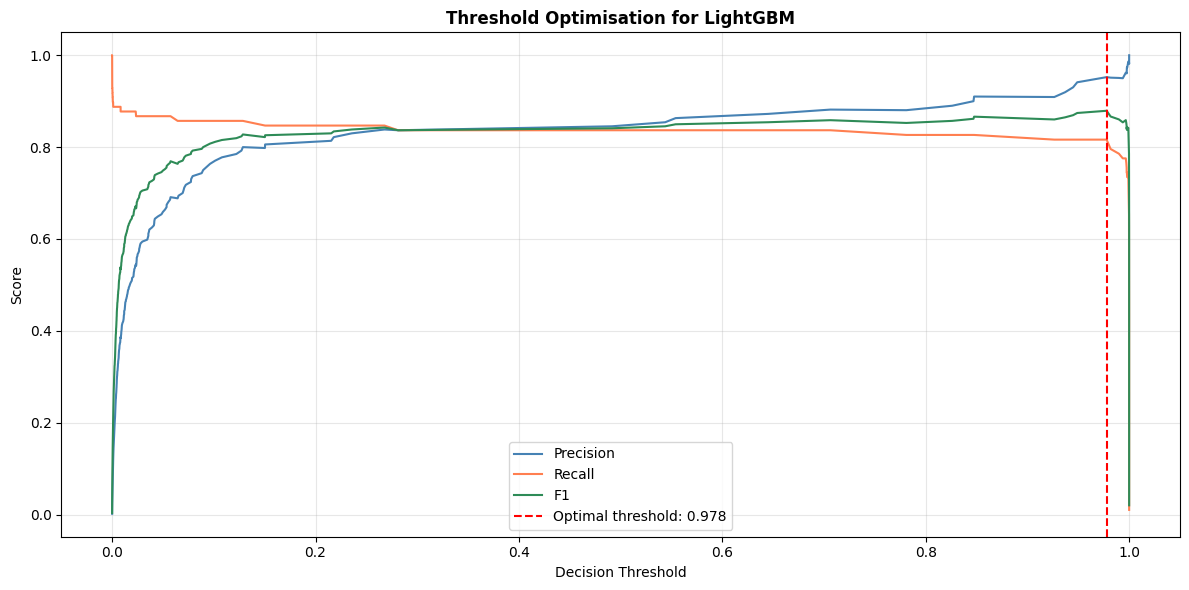

Optimal F1: 0.8791
At threshold: 0.9778
Precision: 0.9524, Recall: 0.8163


In [19]:
 # Threshold optimisation on champion model

# Pick LightGBM as champion (usually strongest)
best_prob = lgb_prob

precisions, recalls, thresholds = precision_recall_curve(y_test, best_prob)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)

optimal_idx = np.argmax(f1_scores[:-1])
optimal_threshold = thresholds[optimal_idx]

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(thresholds, precisions[:-1], label='Precision', color='steelblue')
ax.plot(thresholds, recalls[:-1], label='Recall', color='coral')
ax.plot(thresholds, f1_scores[:-1], label='F1', color='seagreen')
ax.axvline(x=optimal_threshold, color='red', linestyle='--',
           label=f'Optimal threshold: {optimal_threshold:.3f}')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Score')
ax.set_title('Threshold Optimisation for LightGBM', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('images/threshold_optimisation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Optimal F1: {f1_scores[optimal_idx]:.4f}")
print(f"At threshold: {optimal_threshold:.4f}")
print(f"Precision: {precisions[optimal_idx]:.4f}, Recall: {recalls[optimal_idx]:.4f}")

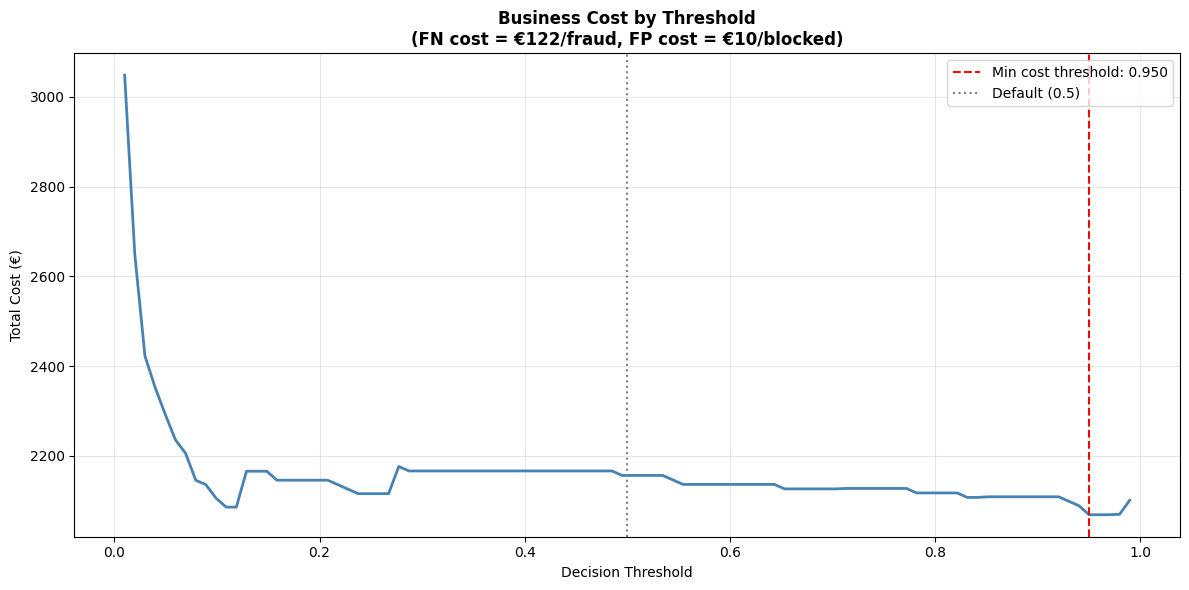

Optimal (min-cost) threshold: 0.9504
Cost at min: €2068.60
Cost at default 0.5: €2156.21


In [21]:
# Cost-benefit analysis

# Assume: false negative = full transaction amount lost (average €88 for fraud)
# false positive = customer friction cost (assume €10 per blocked legitimate transaction)

FALSE_NEG_COST = df[df['Class'] == 1]['Amount'].mean()  # average fraud amount
FALSE_POS_COST = 10  # customer friction estimate

def compute_cost(threshold, probs, y_true, amounts):
    preds = (probs >= threshold).astype(int)
    fn_mask = (preds == 0) & (y_true == 1)
    fp_mask = (preds == 1) & (y_true == 0)
    fn_cost = amounts[fn_mask].sum()
    fp_cost = fp_mask.sum() * FALSE_POS_COST
    return fn_cost + fp_cost

test_amounts = X_test['Amount'].values

thresholds_range = np.linspace(0.01, 0.99, 100)
costs = [compute_cost(t, best_prob, y_test.values, test_amounts) for t in thresholds_range]

optimal_cost_idx = np.argmin(costs)
optimal_cost_threshold = thresholds_range[optimal_cost_idx]

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(thresholds_range, costs, color='steelblue', linewidth=2)
ax.axvline(x=optimal_cost_threshold, color='red', linestyle='--',
           label=f'Min cost threshold: {optimal_cost_threshold:.3f}')
ax.axvline(x=0.5, color='gray', linestyle=':',
           label='Default (0.5)')
ax.set_xlabel('Decision Threshold')
ax.set_ylabel('Total Cost (€)')
ax.set_title(f'Business Cost by Threshold\n(FN cost = €{FALSE_NEG_COST:.0f}/fraud, FP cost = €{FALSE_POS_COST}/blocked)',
             fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('images/cost_benefit_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Optimal (min-cost) threshold: {optimal_cost_threshold:.4f}")
print(f"Cost at min: €{costs[optimal_cost_idx]:.2f}")
print(f"Cost at default 0.5: €{compute_cost(0.5, best_prob, y_test.values, test_amounts):.2f}")

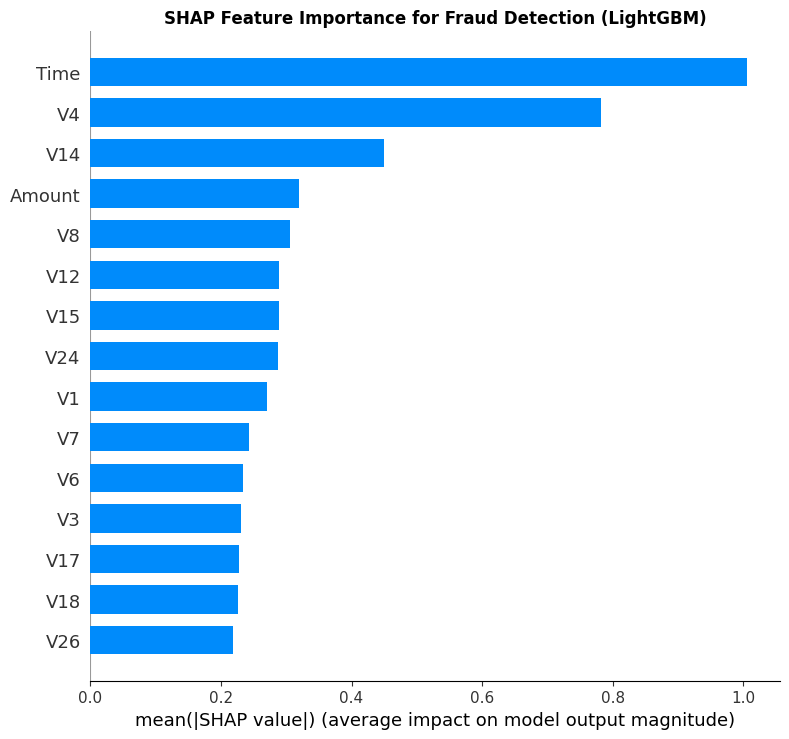

In [22]:
# SHAP on LightGBM champion

X_test_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)
X_sample = X_test_df.sample(3000, random_state=42)

explainer = shap.TreeExplainer(lgb_model)
shap_values = explainer.shap_values(X_sample)

if isinstance(shap_values, list):
    shap_values = shap_values[1]

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_sample, plot_type='bar', max_display=15, show=False)
plt.title('SHAP Feature Importance for Fraud Detection (LightGBM)', fontweight='bold')
plt.tight_layout()
plt.savefig('images/shap_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
#                                                                                                                            